c:\Users\almei\Documents\GitHub\precision-data


c:\Users\almei\Documents\GitHub\precision-data\.venv\Lib\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


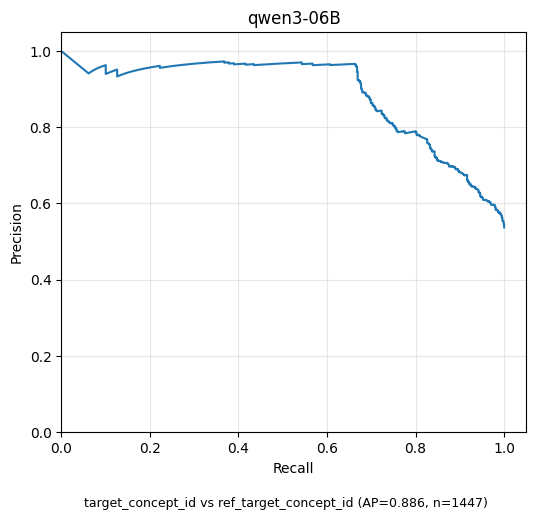

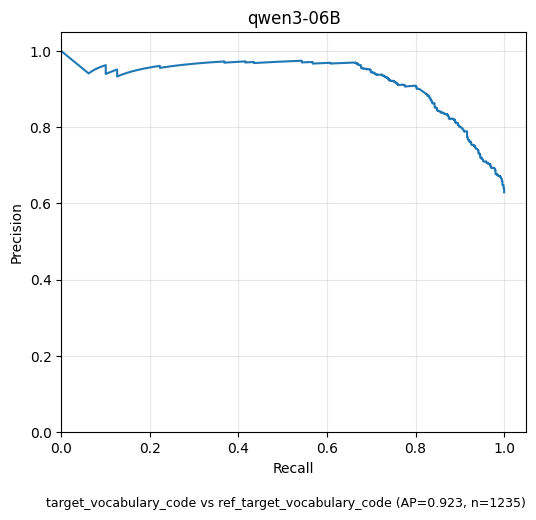

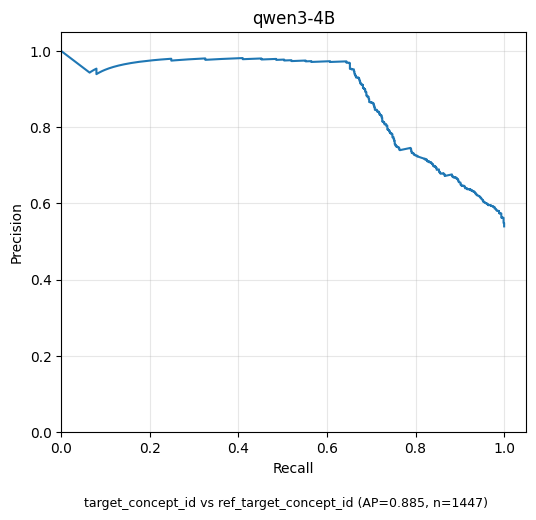

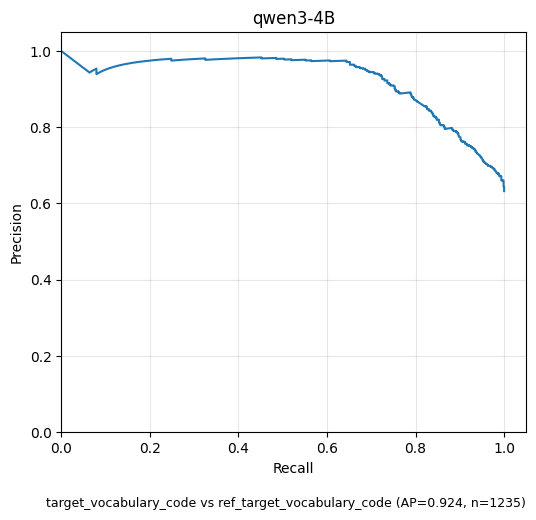

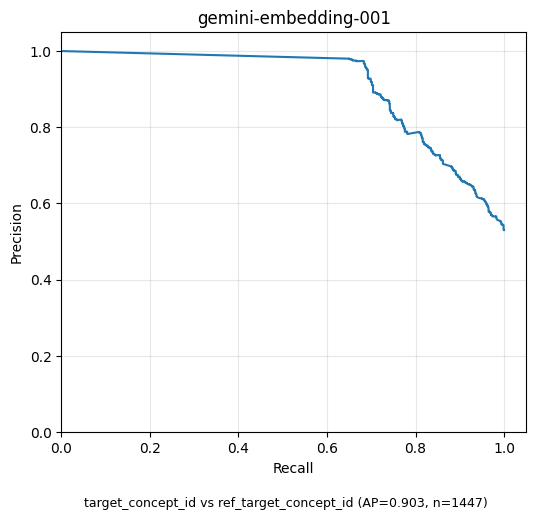

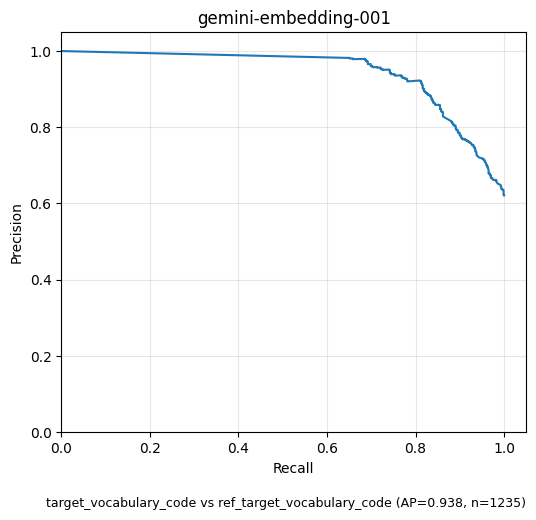

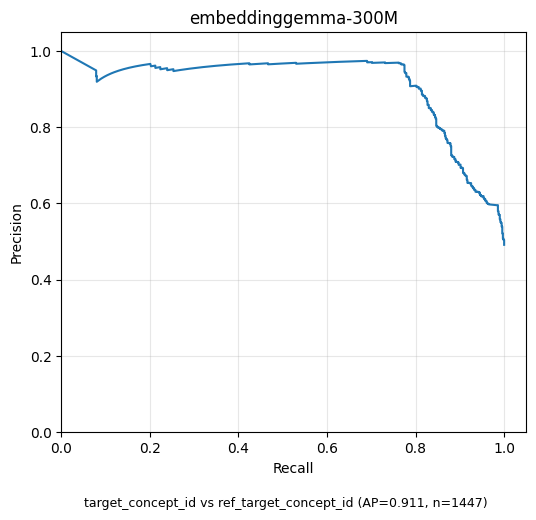

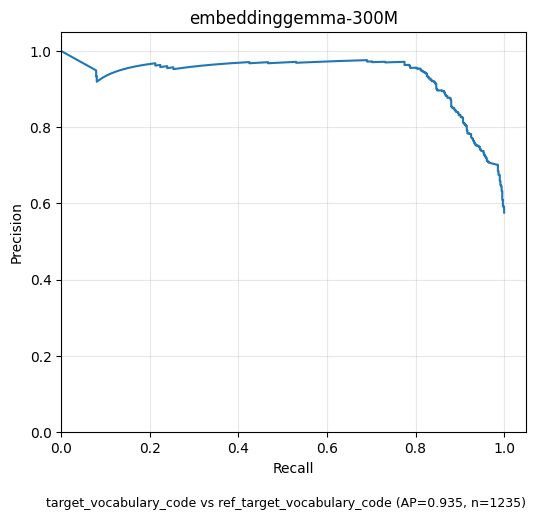

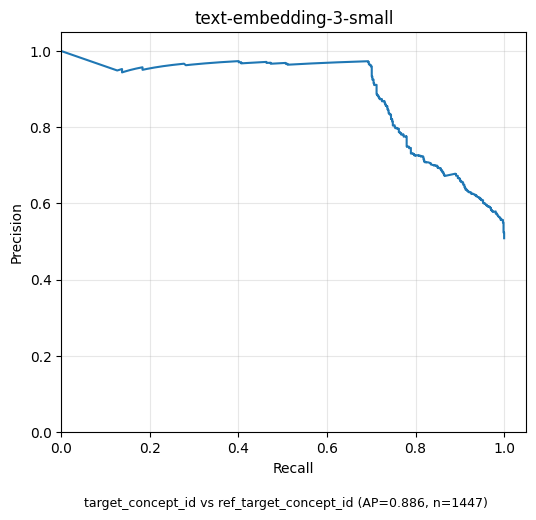

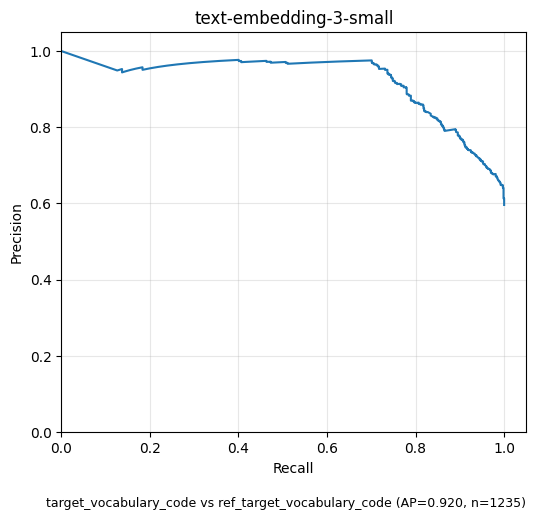

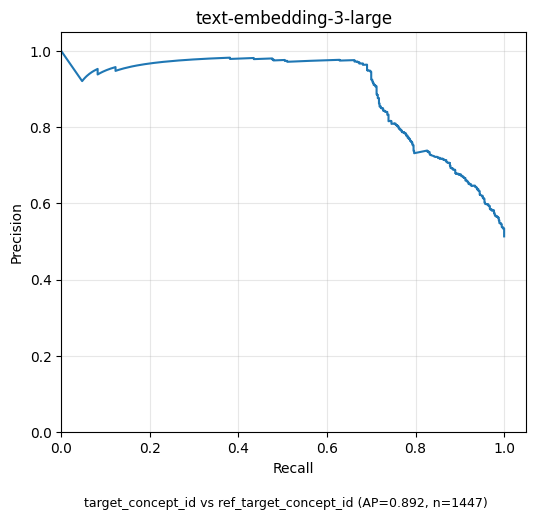

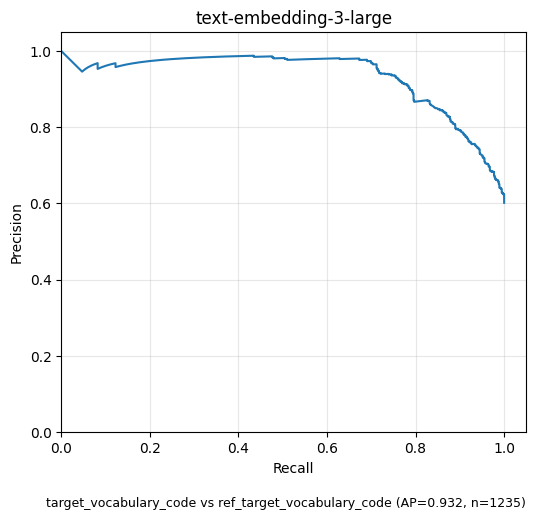

In [1]:
%cd c:\Users\almei\Documents\GitHub\precision-data

from pathlib import Path
import pandas as pd
from pathlib import Path
import yaml
import pandas as pd
import sqlite3
from tqdm import tqdm
from functools import lru_cache
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

from aatm.embedding_functions import Qwen3EmbeddingFunction
from aatm.retrievers import CHROMADB_RETRIEVER_MODEL_REGISTRY


def pr_data(df, pred_col, true_col, score_col="confidence_score"):
    sub = df[[pred_col, true_col, score_col]].copy()
    sub = sub.dropna(subset=[pred_col, true_col, score_col])
    # string compare safe: cast to str for codes; for ids keep as int-ish but str also ok.
    y_true = (sub[pred_col].astype(str) == sub[true_col].astype(str)).astype(int).to_numpy()
    scores = sub[score_col].astype(float).to_numpy()
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    return y_true, scores, precision, recall, thresholds, ap, len(sub)

def plot_pr(precision, recall, title, caption, outfile):
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.plot(recall, precision)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim([0, 1.05])
    ax.set_ylim([0, 1.05])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # ---- caption (figure-level) ----
    fig.text(
        0.5,          # x (center)
        -0.05,        # y (below axes)
        caption,
        ha="center",
        va="top",
        fontsize=9,
        wrap=True,
    )

    # Reserve space for caption
    fig.subplots_adjust(bottom=0.08)

    fig.savefig(
        outfile,
        dpi=200,
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()
    plt.close(fig)

ref_path = Path("vocabularies/SOURCE_TO_CONCEPT_MAP_revised.csv")

ref_df = pd.read_csv(ref_path).dropna(subset=["target_concept_id"])
ref_df['target_concept_id'] = ref_df['target_concept_id'].astype(int).astype(str)

datasets_base_path = Path("datasets")
datasets_base_path.mkdir(exist_ok=True)

model_registry = CHROMADB_RETRIEVER_MODEL_REGISTRY

for model_name in model_registry:
    eval_path = Path(f'output/{model_name}/mapped_source_concepts.csv')
    eval_df = pd.read_csv(eval_path)
    
    # select rows in the same order in both dfs by source_code
    ref_df = ref_df.sort_values('source_code')
    eval_df = eval_df.sort_values('source_code').reset_index(drop=True)

    ref_df_filtered = ref_df[ref_df['source_code'].isin(eval_df['source_code'])].reset_index(drop=True)
    eval_df_filtered = eval_df

    assert ref_df_filtered.shape[0] == eval_df_filtered.shape[0]
    assert ref_df_filtered['source_code'].tolist() == eval_df_filtered['source_code'].tolist()

    eval_df_filtered['target_concept_id_match'] = ref_df_filtered['target_concept_id'] == eval_df_filtered['target_concept_id'].astype(str)
    eval_df_filtered['ref_target_concept_id'] = ref_df_filtered['target_concept_id']
    eval_df_filtered['ref_target_vocabulary_code'] = ref_df_filtered['target_vocabulary_code']
    eval_df_filtered.to_csv(Path(model_registry[model_name]["output_path"])/"output_vs_ref.csv")

    # 1) concept_id
    y1, s1, p1, r1, t1, ap1, n1 = pr_data(
        eval_df_filtered, 
        "target_concept_id", 
        "ref_target_concept_id")
    plot_pr(
        p1, 
        r1, 
        title=f"{model_name}", 
        caption=f"target_concept_id vs ref_target_concept_id (AP={ap1:.3f}, n={n1})", 
        outfile=Path(model_registry[model_name]["output_path"])/"pr_concept_id.png")

    # 2) vocabulary_code
    y2, s2, p2, r2, t2, ap2, n2 = pr_data(eval_df_filtered, "target_vocabulary_code", "ref_target_vocabulary_code")
    plot_pr(
        p2, 
        r2, 
        title=f"{model_name}", 
        caption=f"target_vocabulary_code vs ref_target_vocabulary_code (AP={ap2:.3f}, n={n2})", 
        outfile=Path(model_registry[model_name]["output_path"])/"pr_vocabulary_code.png"
        )

c:\Users\almei\Documents\GitHub\precision-data


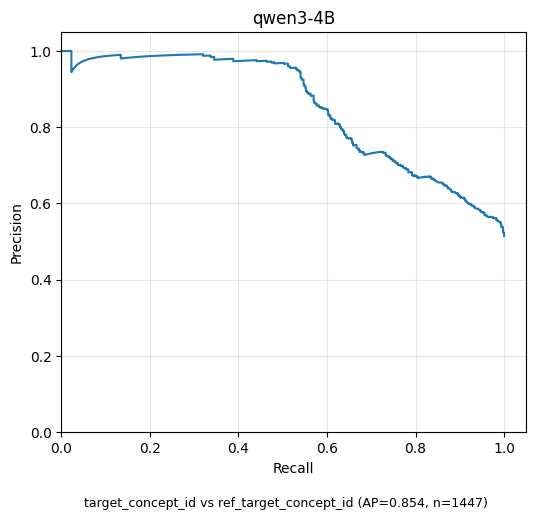

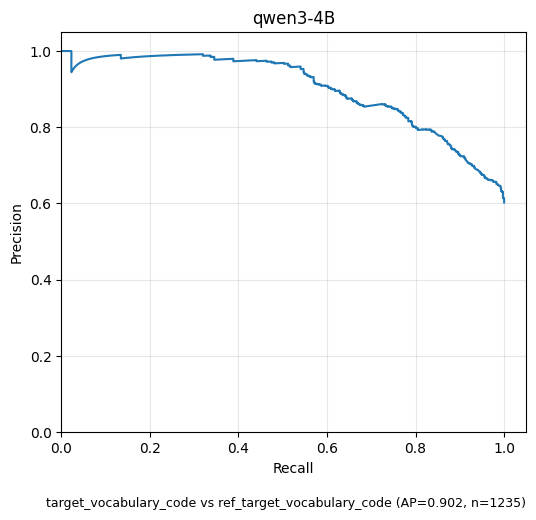

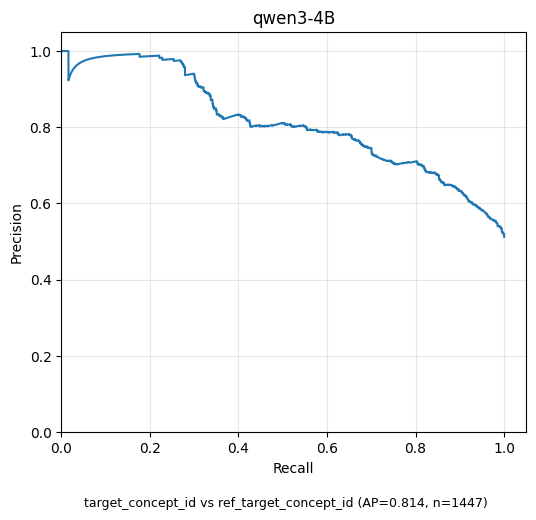

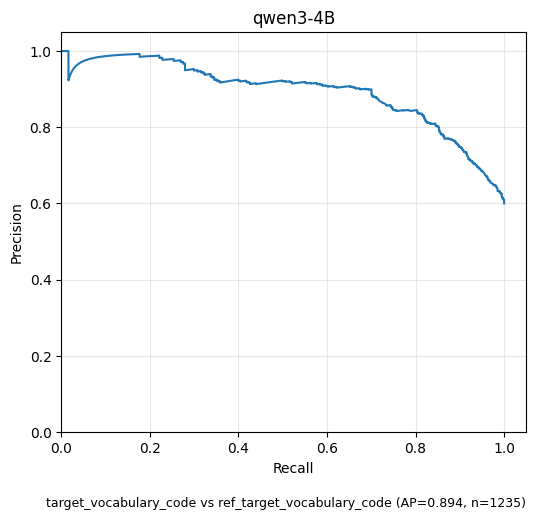

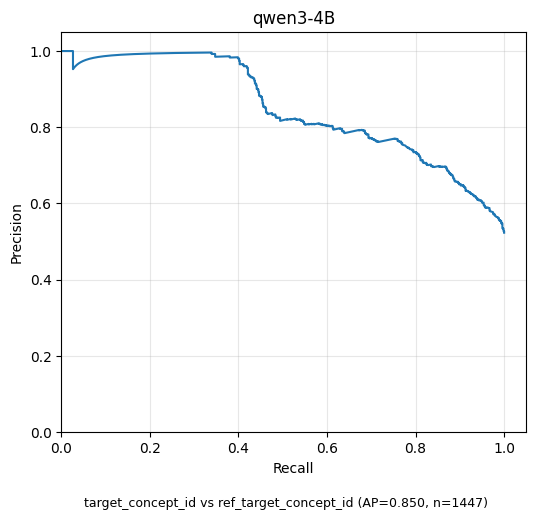

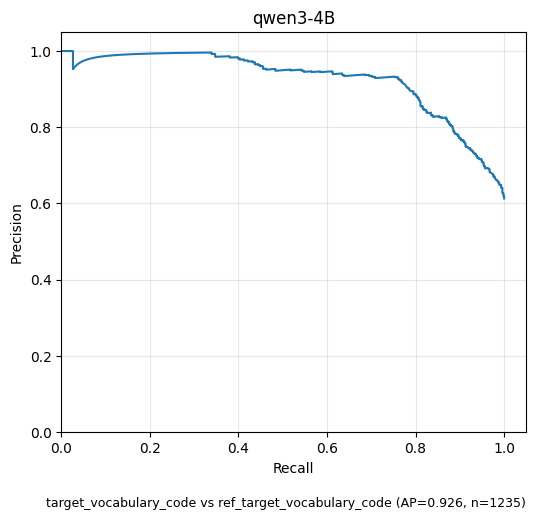

In [12]:
%cd c:\Users\almei\Documents\GitHub\precision-data

from pathlib import Path
import pandas as pd
from pathlib import Path
import yaml
import pandas as pd
import sqlite3
from tqdm import tqdm
from functools import lru_cache
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

from aatm.embedding_functions import Qwen3EmbeddingFunction
from aatm.rerankers import Qwen3RerankerModels
from aatm.retrievers import CHROMADB_RETRIEVER_MODEL_REGISTRY


def pr_data(df, pred_col, true_col, score_col="confidence_score"):
    sub = df[[pred_col, true_col, score_col]].copy()
    sub = sub.dropna(subset=[pred_col, true_col, score_col])
    # string compare safe: cast to str for codes; for ids keep as int-ish but str also ok.
    y_true = (sub[pred_col].astype(str) == sub[true_col].astype(str)).astype(int).to_numpy()
    scores = sub[score_col].astype(float).to_numpy()
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    return y_true, scores, precision, recall, thresholds, ap, len(sub)

def plot_pr(precision, recall, title, caption, outfile):
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.plot(recall, precision)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim([0, 1.05])
    ax.set_ylim([0, 1.05])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # ---- caption (figure-level) ----
    fig.text(
        0.5,          # x (center)
        -0.05,        # y (below axes)
        caption,
        ha="center",
        va="top",
        fontsize=9,
        wrap=True,
    )

    # Reserve space for caption
    fig.subplots_adjust(bottom=0.08)

    fig.savefig(
        outfile,
        dpi=200,
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()
    plt.close(fig)

ref_path = Path("vocabularies/SOURCE_TO_CONCEPT_MAP_revised.csv")

ref_df = pd.read_csv(ref_path).dropna(subset=["target_concept_id"])
ref_df['target_concept_id'] = ref_df['target_concept_id'].astype(int).astype(str)

datasets_base_path = Path("datasets")
datasets_base_path.mkdir(exist_ok=True)

model_registry = CHROMADB_RETRIEVER_MODEL_REGISTRY

for model_name in ["qwen3-4B"]:
    for reranker_name in ["BM25", Qwen3RerankerModels.QWEN3_06B.value,
        Qwen3RerankerModels.QWEN3_4B.value]:
        eval_path = Path(f'output/{model_name}/with-reranker/{reranker_name}/mapped_source_concepts.csv')
        eval_df = pd.read_csv(eval_path)
        
        # select rows in the same order in both dfs by source_code
        ref_df = ref_df.sort_values('source_code')
        eval_df = eval_df.sort_values('source_code').reset_index(drop=True)

        ref_df_filtered = ref_df[ref_df['source_code'].isin(eval_df['source_code'])].reset_index(drop=True)
        eval_df_filtered = eval_df

        assert ref_df_filtered.shape[0] == eval_df_filtered.shape[0]
        assert ref_df_filtered['source_code'].tolist() == eval_df_filtered['source_code'].tolist()

        eval_df_filtered['target_concept_id_match'] = ref_df_filtered['target_concept_id'] == eval_df_filtered['target_concept_id'].astype(str)
        eval_df_filtered['ref_target_concept_id'] = ref_df_filtered['target_concept_id']
        eval_df_filtered['ref_target_vocabulary_code'] = ref_df_filtered['target_vocabulary_code']
        eval_df_filtered.to_csv(Path(model_registry[model_name]["output_path"])/"output_vs_ref.csv")

        # 1) concept_id
        y1, s1, p1, r1, t1, ap1, n1 = pr_data(
            eval_df_filtered, 
            "target_concept_id", 
            "ref_target_concept_id")
        plot_pr(
            p1, 
            r1, 
            title=f"{model_name}", 
            caption=f"target_concept_id vs ref_target_concept_id (AP={ap1:.3f}, n={n1})", 
            outfile=Path(model_registry[model_name]["output_path"], f"with-reranker/{reranker_name}")/"pr_concept_id.png")

        # 2) vocabulary_code
        y2, s2, p2, r2, t2, ap2, n2 = pr_data(eval_df_filtered, "target_vocabulary_code", "ref_target_vocabulary_code")
        plot_pr(
            p2, 
            r2, 
            title=f"{model_name}", 
            caption=f"target_vocabulary_code vs ref_target_vocabulary_code (AP={ap2:.3f}, n={n2})", 
            outfile=Path(model_registry[model_name]["output_path"], f"with-reranker/{reranker_name}")/"pr_vocabulary_code.png"
            )

In [3]:
%cd c:\Users\almei\Documents\GitHub\precision-data

from pathlib import Path
import pandas as pd
from pathlib import Path
import yaml
import pandas as pd
import sqlite3
from tqdm import tqdm
from functools import lru_cache
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import json
from aatm.embedding_functions import Qwen3EmbeddingFunction
from aatm.retrievers import CHROMADB_RETRIEVER_MODEL_REGISTRY
from aatm.selectors import GeminiLLMModels


def pr_data(df, pred_col, true_col, score_col="confidence_score"):
    sub = df[[pred_col, true_col, score_col]].copy()
    sub = sub.dropna(subset=[pred_col, true_col, score_col])
    # string compare safe: cast to str for codes; for ids keep as int-ish but str also ok.
    y_true = (sub[pred_col].astype(str) == sub[true_col].astype(str)).astype(int).to_numpy()
    scores = sub[score_col].astype(float).to_numpy()
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    return y_true, scores, precision, recall, thresholds, ap, len(sub)

def plot_pr(precision, recall, title, caption, outfile):
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.plot(recall, precision)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim([0, 1.05])
    ax.set_ylim([0, 1.05])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # ---- caption (figure-level) ----
    fig.text(
        0.5,          # x (center)
        -0.05,        # y (below axes)
        caption,
        ha="center",
        va="top",
        fontsize=9,
        wrap=True,
    )

    # Reserve space for caption
    fig.subplots_adjust(bottom=0.08)

    fig.savefig(
        outfile,
        dpi=200,
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()
    plt.close(fig)

def save_metrics(metrics, outfile):
    with open(outfile, 'w') as f:
        json.dump(metrics, f, indent=4)

ref_path = Path("vocabularies/SOURCE_TO_CONCEPT_MAP_revised.csv")

ref_df = pd.read_csv(ref_path).dropna(subset=["target_concept_id"])
ref_df['target_concept_id'] = ref_df['target_concept_id'].astype(int).astype(str)

datasets_base_path = Path("datasets")
datasets_base_path.mkdir(exist_ok=True)

model_registry = CHROMADB_RETRIEVER_MODEL_REGISTRY

for model_name in ["gemini-embedding-001"]:
    for llm_selector_name in [GeminiLLMModels.GEMINI_2_5_FLASH.value]:
        eval_path = Path(f'output/{model_name}/with-llm-selector/{llm_selector_name}/mapped_source_concepts.csv')
        eval_df = pd.read_csv(eval_path)
        
        # select rows in the same order in both dfs by source_code
        ref_df = ref_df.sort_values('source_code')
        eval_df = eval_df.sort_values('source_code').reset_index(drop=True)

        ref_df_filtered = ref_df[ref_df['source_code'].isin(eval_df['source_code'])].reset_index(drop=True)
        eval_df_filtered = eval_df

        assert ref_df_filtered.shape[0] == eval_df_filtered.shape[0]
        assert ref_df_filtered['source_code'].tolist() == eval_df_filtered['source_code'].tolist()

        eval_df_filtered['target_concept_id_match'] = ref_df_filtered['target_concept_id'] == eval_df_filtered['target_concept_id'].fillna(-1).astype(int).astype(str)
        eval_df_filtered['ref_target_concept_id'] = ref_df_filtered['target_concept_id']
        eval_df_filtered['ref_target_vocabulary_code'] = ref_df_filtered['target_vocabulary_code']
        eval_df_filtered.to_csv(Path(model_registry[model_name]["output_path"])/f"with-llm-selector/{llm_selector_name}"/"output_vs_ref.csv")

        true_positives = eval_df_filtered['target_concept_id_match'].value_counts()[True].item()
        false_negatives = eval_df_filtered['target_concept_id'].isna().sum().item()
        false_positives = len(eval_df_filtered['target_concept_id_match']) - false_negatives - true_positives

        print(f"True positives: {true_positives}")
        print(f"False positives: {false_positives}")
        print(f"False negatives: {false_negatives}")

        precision = true_positives / (true_positives + false_positives)
        recall = true_positives / (true_positives + false_negatives)

        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1: {2 * (precision * recall) / (precision + recall)}")

        save_metrics({
            "true_positives": true_positives,
            "false_positives": false_positives,
            "false_negatives": false_negatives,
            "precision": precision,
            "recall": recall,
            "f1_score": 2 * (precision * recall) / (precision + recall),
        }, Path(model_registry[model_name]["output_path"])/f"with-llm-selector/{llm_selector_name}"/"metrics.json")

c:\Users\almei\Documents\GitHub\precision-data
True positives: 721
False positives: 548
False negatives: 178
Precision: 0.5681639085894405
Recall: 0.8020022246941045
F1: 0.665129151291513
